In [74]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

In [75]:
COLUMN_MAP = {# Блок 1 
    "b1_q1_year": "Год рождения",
    "b1_q2_gender": "Пол",
    "b1_q3_education": "Образование",
    "b1_q4_family": "Семейное положение",
    "b1_q5_savings_share": "Доля сбережений",
    # Блок 2
    "b2_q1_goal": "Инвестиционная цель",
    "b2_q2_horizon": "Срок инвестирования",
    "b2_q3_drop": "Реакция на падение 15%",
    "b2_q4_gain": "Реакция на рост 20%",
    "b2_q5_risky_allocation": "Доля в рискованный проект",
    "b2_q6_guaranteed_vs_volatile": "Выбор между А и Б",
    "b2_q7_experience": "Инвестиционный опыт",
    # Блок 3 — финансовая грамотность
    "b3_q1_compound": "Грамотность Q1",
    "b3_q2_inflation": "Грамотность  Q2",
    "b3_q3_etf": "Грамотность Q3",
    "b3_q4_bonds": "Грамотность Q4",
    "b3_q5_diversification": "Грамотность Q5",
    # Блок 4 — стадный эффект 
    "b4_q1_popular": "Стадный Q1",
    "b4_q2_social": "Стадный Q2",
    "b4_q3_bloggers": "Стадный Q3",
    "b4_q4_trending": "Стадный Q4",
    "b4_q5_friends": "Стадный Q5",
    "b4_q6_broker_top": "Стадный Q6",
    # Блок 5 — использование финтеха
    "b5_q1_portfolio_check": "Частота проверки портфеля",
    "b5_q2_instruments": "Финтех-инструменты",
    "b5_q3_push": "Решения под push-уведомлениями",
    "b5_q4_autoinvest": "Автоинвестирование",
    "b5_q5_impulse": "Импульсивные сделки",}



In [76]:
GOAL_SCORES = {
    "Сохранение капитала, защита от инфляции (минимальный риск)": 1,
    "Стабильный, но небольшой рост капитала": 2,
    "Сбалансированный рост и доходность": 3,
    "Активный рост капитала (готов(а) к колебаниям)": 4,
    "Максимальная доходность (готов(а) к высоким рискам)": 5,
}

HORIZON_SCORES = {
    "1–3 года": 1,
    "3–5 лет": 2,
    "5–10 лет": 3,
    "Более 10 лет": 4,
}

DROP_SCORES = {
    "Продам все активы, чтобы избежать дальнейших потерь": 1,
    "Продам часть, переведу в более надежные инструменты": 2,
    "Ничего не буду делать, подожду восстановления": 3,
    "Докуплю активы, так как они стали дешевле": 4,
}

GAIN_SCORES = {
    "Зафиксирую всю прибыль и переведу деньги в надежные активы": 1,
    "Зафиксирую часть прибыли, остальное оставлю": 2,
    "Оставлю всё как есть, продолжая держать": 3,
    "Доложу еще средств, так как стратегия работает": 4,
}

RISKY_ALLOC_SCORES = {
    "0% (это не для меня)": 1,
    "Менее 5%": 2,
    "5–15%": 3,
    "16-30%": 4,
    "Более 30%": 5,
}

GUARANTEED_SCORES = {
    "Однозначно вариант А (гарантированный доход)": 1,
    "Скорее вариант А, но вариант Б тоже рассматривал(а) бы": 2,
    "Затрудняюсь выбрать / мне нужно больше информации": 3,
    "Скорее вариант Б, понимая риски": 4,
    "Однозначно вариант Б (максимальная доходность)": 5,
}

EXPERIENCE_WEIGHTS = {
    "Банковские вклады, накопительные счета": 0,
    "Драгоценные металлы (золото, серебро)": 1,
    "Накопительное/инвестиционное страхование жизни": 1,
    "Инвестиционные паи": 2,
    "Доверительное управление": 2,
    "Облигации": 2,
    "Акции": 3,
    "Структурные ноты": 4,
    "Производные финансовые инструменты (фьючерсы, опционы…)": 4,
    "Криптовалюта": 5,
    "Форекс": 5,
}


CORRECT_LITERACY = {
    "b3_q1_compound": "Больше 110 000 рублей",  
    "b3_q2_inflation": "Меньше, чем сегодня",
    "b3_q3_etf": "Неверно",
    "b3_q4_bonds": "Цена облигации обычно падает",
    "b3_q5_diversification": "Распределение инвестиций между разными активами для снижения риска",
}

# Блок 5: балл за каждый вариант и максимально возможный балл для вопроса (используются для min-max нормализации)

FINTECH_FREQ_SCORES = {  # Q1
    "Не пользуюсь мобильными приложениями для инвестиций": 0,
    "Раз в неделю или реже": 1,
    "Несколько раз в неделю": 2,
    "Раз в день": 3,
    "Несколько раз в день": 4,
}
FINTECH_FREQ_MAX = 4

FINTECH_INSTRUMENTS_WEIGHTS = {  # Q2
    "Мобильное приложение брокера (Тинькофф Инвестиции, СберИнвестиции, ВТБ Мои Инвестиции и др.)": 1,
    "Криптовалютная биржа": 2,
    "Робо-эдвайзинг (автоматические рекомендации)": 2,
    "P2P-платформы (кредитование физических лиц)": 2,
    "Краудфандинговые платформы": 2,
    "Не пользовался(ась) ничем из перечисленного": 0,
}
FINTECH_INSTRUMENTS_MAX = sum(
    v for k, v in FINTECH_INSTRUMENTS_WEIGHTS.items() if k != "Не пользовался(ась) ничем из перечисленного"
)  # = 9

FINTECH_PUSH_SCORES = {  # Q3
    "Нет, никогда": 0,
    "Я отключил(а) push-уведомления / не получаю их": 0,
    "Да, был один-два случая": 1,
    "Да, иногда (несколько раз в год)": 2,
    "Да, регулярно (несколько раз в месяц)": 3,
}
FINTECH_PUSH_MAX = 3

FINTECH_AUTOINVEST_SCORES = {  # Q4
    "Не знаю о такой возможности": 0,
    "Нет": 0,
    "Да": 1,
}
FINTECH_AUTOINVEST_MAX = 1

FINTECH_IMPULSE_SCORES = {  # Q5
    "Нет, никогда": 0,
    "Да, иногда": 1,
    "Да, часто": 2,
}
FINTECH_IMPULSE_MAX = 2


In [95]:
def score_experience(cell) -> int:
    
    if pd.isna(cell):
        return 0
    if isinstance(cell, list):
        items = cell
    else:
        items = [x.strip() for x in str(cell).replace(";", ",").split(",")]
    return sum(EXPERIENCE_WEIGHTS.get(item, 0) for item in items)


def score_fintech_instruments(cell) -> int:
    
    if pd.isna(cell):
        return 0
    if isinstance(cell, list):
        items = cell
    else:
        items = [x.strip() for x in str(cell).replace(";", ",").split(",")]
    return sum(FINTECH_INSTRUMENTS_WEIGHTS.get(item, 0) for item in items)


def compute_risk_score(row: pd.Series) -> float:
    
    score = 0
    score += GOAL_SCORES.get(row.get("b2_q1_goal"), 0)
    score += HORIZON_SCORES.get(row.get("b2_q2_horizon"), 0)
    score += DROP_SCORES.get(row.get("b2_q3_drop"), 0)
    score += GAIN_SCORES.get(row.get("b2_q4_gain"), 0)
    score += RISKY_ALLOC_SCORES.get(row.get("b2_q5_risky_allocation"), 0)
    score += GUARANTEED_SCORES.get(row.get("b2_q6_guaranteed_vs_volatile"), 0)
    exp_score = score_experience(row.get("b2_q7_experience"))
    
    exp_score_capped = min(exp_score, 15)
    score += exp_score_capped
    return score


def classify_risk_profile(score: float) -> str:
    
    if score <= 13:
        return "Консервативный"
    if score <= 20:
        return "Умеренно-консервативный"
    if score <= 27:
        return "Умеренный"
    if score <= 34:
        return "Умеренно-агрессивный"
    return "Агрессивный"


RISK_CATEGORY_ORDER = [
    "Консервативный",
    "Умеренно-консервативный",
    "Умеренный",
    "Умеренно-агрессивный",
    "Агрессивный",
]


def compute_literacy_score(row: pd.Series) -> int:
    
    score = 0
    for col, correct in CORRECT_LITERACY.items():
        if str(row.get(col, "")).strip() == correct:
            score += 1
    return score


def compute_herding_score(row: pd.Series) -> float:
    
    cols = [f"b4_q{i}_{suffix}" for i, suffix in enumerate(
        ["popular", "social", "bloggers", "trending", "friends", "broker_top"], start=1
    )]
    values = [row.get(c) for c in cols]
    values = [float(v) for v in values if v is not None and not pd.isna(v)]
    return np.mean(values) if values else np.nan


def compute_fintech_score(row: pd.Series) -> float:
    
    components = []

    v1 = FINTECH_FREQ_SCORES.get(row.get("b5_q1_portfolio_check"))
    if v1 is not None:
        components.append(v1 / FINTECH_FREQ_MAX)

    v2 = score_fintech_instruments(row.get("b5_q2_instruments"))
    components.append(min(v2, FINTECH_INSTRUMENTS_MAX) / FINTECH_INSTRUMENTS_MAX)

    v3 = FINTECH_PUSH_SCORES.get(row.get("b5_q3_push"))
    if v3 is not None:
        components.append(v3 / FINTECH_PUSH_MAX)

    v4 = FINTECH_AUTOINVEST_SCORES.get(row.get("b5_q4_autoinvest"))
    if v4 is not None:
        components.append(v4 / FINTECH_AUTOINVEST_MAX)

    v5 = FINTECH_IMPULSE_SCORES.get(row.get("b5_q5_impulse"))
    if v5 is not None:
        components.append(v5 / FINTECH_IMPULSE_MAX)

    return np.mean(components) if components else np.nan

def load_data(path: str, column_map: dict | None = None) -> pd.DataFrame:
    
    if path.endswith(".csv"):
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)

    if column_map:
        inverse = {v: k for k, v in column_map.items()}
        df = df.rename(columns=inverse)
    return df

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.drop_duplicates().copy()
    generation_mapping = {
        "1982-2000": "Y (миллениалы)", "2001-2008": "Z (зумеры)",
    }
    raw_age_col = df["b1_q1_year"]
    df["generation"] = raw_age_col.map(generation_mapping)
    assert df["generation"].notna().all(),"не все ответы о возрасте распознаны"
    
    return df


def build_indices(df: pd.DataFrame) -> pd.DataFrame:
    
    df = df.copy()
    df["risk_score"] = df.apply(compute_risk_score, axis=1)
    df["risk_category"] = df["risk_score"].apply(classify_risk_profile)
    df["risk_category"] = pd.Categorical(
        df["risk_category"], categories=RISK_CATEGORY_ORDER, ordered=True
    )
    df["literacy_score"] = df.apply(compute_literacy_score, axis=1)
    df["herding_score"] = df.apply(compute_herding_score, axis=1)
    df["fintech_score"] = df.apply(compute_fintech_score, axis=1)
    df["gen_binary"] = (df["generation"] == "Z (зумеры)").astype(int)
    return df


def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Выявляет выбросы по правилу Тьюки."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)


def descriptive_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Сводная статистика по индексам в разрезе поколений."""
    grouped = df.groupby("generation")[
        ["risk_score", "literacy_score", "herding_score", "fintech_score"]
    ].agg(["mean", "median", "std", "min", "max", "count"])
    return grouped.round(3)


def risk_category_distribution(df: pd.DataFrame) -> pd.DataFrame:
    """Распределение по категориям риск-профиля (в %)."""
    ct = pd.crosstab(df["generation"], df["risk_category"], normalize="index") * 100
    for cat in RISK_CATEGORY_ORDER:
        if cat not in ct.columns:
            ct[cat] = 0.0
    ct = ct[RISK_CATEGORY_ORDER]
    return ct.round(2)



def cohen_d(a: np.ndarray, b: np.ndarray) -> float:
    """Размер эффекта d Коэна для двух независимых выборок."""
    na, nb = len(a), len(b)
    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1) * sa + (nb - 1) * sb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else np.nan


def run_t_test(df: pd.DataFrame, var: str, alt: str = "two-sided") -> dict:
    """
    Проводит t-тест Стьюдента для независимых выборок (поколения Y vs Z).
    Сначала проверяется равенство дисперсий (тест Левена), затем
    применяется t-тест с соответствующей поправкой.
    """
    y = df.loc[df["generation"] == "Y (миллениалы)", var].dropna().values
    z = df.loc[df["generation"] == "Z (зумеры)", var].dropna().values

    levene_stat, levene_p = stats.levene(y, z)
    equal_var = levene_p > 0.05
    t_stat, p_two = stats.ttest_ind(y, z, equal_var=equal_var)

    if alt == "two-sided":
        p_value = p_two
    elif alt == "less":
        # H1: среднее Y < среднее Z
        p_value = p_two / 2 if t_stat < 0 else 1 - p_two / 2
    elif alt == "greater":
        # H1: среднее Y > среднее Z
        p_value = p_two / 2 if t_stat > 0 else 1 - p_two / 2
    else:
        raise ValueError("alt должен быть 'two-sided', 'less' или 'greater'")

    return {
        "variable": var,
        "n_Y": len(y),
        "n_Z": len(z),
        "mean_Y": np.mean(y),
        "mean_Z": np.mean(z),
        "std_Y": np.std(y, ddof=1),
        "std_Z": np.std(z, ddof=1),
        "levene_p": levene_p,
        "equal_var": equal_var,
        "t": t_stat,
        "p_two_sided": p_two,
        "p_value": p_value,
        "alternative": alt,
        "cohen_d": cohen_d(y, z),
    }


def run_chi_square(df: pd.DataFrame) -> dict:
    """χ² Пирсона для таблицы сопряжённости поколение × категория риск-профиля."""
    ct_full = pd.crosstab(df["generation"], df["risk_category"])
    ct_for_test = ct_full.loc[:, (ct_full.sum(axis=0) > 0)]
    chi2, p, dof, expected = stats.chi2_contingency(ct_for_test)
    n = ct_for_test.values.sum()
    r, c = ct_for_test.shape
    cramer_v = np.sqrt(chi2 / (n * (min(r, c) - 1))) if min(r, c) > 1 else np.nan
    return {
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "n": n,
        "cramer_v": cramer_v,
        "contingency": ct_full,
        "contingency_tested": ct_for_test,
        "expected": pd.DataFrame(expected, index=ct_for_test.index, columns=ct_for_test.columns),
    }


def run_regression(df: pd.DataFrame):
    
    model_df = df.dropna(
        subset=["risk_score", "gen_binary", "literacy_score", "herding_score", "fintech_score"]
    )
    formula = "risk_score ~ gen_binary + literacy_score + herding_score + fintech_score"
    model = ols(formula, data=model_df).fit()
    return model




def plot_risk_distribution(df: pd.DataFrame, path: str):
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(11, 6.5))
    ct = pd.crosstab(df["generation"], df["risk_category"], normalize="index") * 100
    for cat in RISK_CATEGORY_ORDER:
        if cat not in ct.columns:
            ct[cat] = 0.0
    ct = ct[RISK_CATEGORY_ORDER]
    
    ct_t = ct.T
    bars = ct_t.plot(
        kind="bar",
        ax=ax,
        color=["#5B9BD5", "#ED7D31"],
        edgecolor="black",
        width=0.75,
    )
    
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=lambda v: f"{v:.1f}%" if v > 0 else "",
            fontsize=10,
            padding=2,
        )
    ax.set_xlabel("Категория риск-профиля", fontsize=13)
    ax.set_ylabel("Доля респондентов, %", fontsize=13)
    ax.set_title(
        "Распределение респондентов по категориям риск-профиля",
        fontsize=14,
        pad=12,
    )
    ax.legend(title="Поколение", fontsize=11, title_fontsize=12)
    ax.set_ylim(0, max(ct.values.max() + 8, 60))
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def plot_boxplots(df: pd.DataFrame, path: str):
    plt.rcParams.update({"font.size": 11})
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    variables = [
        ("risk_score", "Балл риск-профиля"),
        ("literacy_score", "Индекс финансовой грамотности"),
        ("herding_score", "Индекс стадного эффекта"),
        ("fintech_score", "Индекс использования финтеха"),
    ]
    palette = {"Y (миллениалы)": "#5B9BD5", "Z (зумеры)": "#ED7D31"}
    for ax, (var, label) in zip(axes.flatten(), variables):
        sns.boxplot(
            data=df, x="generation", y=var, ax=ax,
            palette=palette, showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white",
                       "markeredgecolor": "black", "markersize": 7},
        )
        sns.stripplot(
            data=df, x="generation", y=var, ax=ax,
            color="black", alpha=0.3, size=3.5, jitter=0.18,
        )
        
        for i, gen in enumerate(df["generation"].unique()):
            mean_val = df.loc[df["generation"] == gen, var].mean()
            ax.annotate(
                f"M = {mean_val:.2f}",
                xy=(i, mean_val),
                xytext=(8, 8),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
                color="#333333",
            )
        ax.set_xlabel("")
        ax.set_ylabel(label, fontsize=12)
        ax.set_title(label, fontsize=13, pad=10)
    fig.suptitle(
        "Распределение интегральных индексов по поколениям",
        fontsize=15, y=1.00, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

def plot_descriptive_table(df: pd.DataFrame, path: str):
    """Таблица описательной статистики: индекс / поколение / среднее / медиана / стд / мин / макс."""
    
    variables = [
        ("risk_score", "Балл риск-профиля"),
        ("literacy_score", "Индекс фин. грамотности"),
        ("herding_score", "Индекс стадного эффекта"),
        ("fintech_score", "Индекс использования финтеха"),
    ]
    generations = ["Y (миллениалы)", "Z (зумеры)"]
    
    stats_list = []
    for var, label in variables:
        for gen in generations:
            data = df.loc[df["generation"] == gen, var]
            stats_list.append({
                "Индекс": label,
                "Поколение": gen,
                "Среднее": data.mean(),
                "Медиана": data.median(),
                "Стд откл": data.std(),
                "Мин": data.min(),
                "Макс": data.max(),
                "N": len(data)
            })
    
    stats_df = pd.DataFrame(stats_list)
    
    stats_df_rounded = stats_df.round(2)
    
    fig, ax = plt.subplots(figsize=(14, 5.5))
    ax.axis("off")
    
    table = ax.table(
        cellText=stats_df_rounded.values,
        colLabels=stats_df.columns,
        cellLoc="center",
        loc="center",
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.6)
    
    header_color = "#4472C4"
    for j in range(len(stats_df.columns)):
        table[(0, j)].set_facecolor(header_color)
        table[(0, j)].set_text_props(color="white", fontweight="bold")
    
    
    index_colors = ["#D6E4F0", "#FCE4D6", "#E2EFDA", "#F2E8F5"]  
    
    for row_idx in range(len(stats_list)):
        color_idx = row_idx // 2  
        color = index_colors[color_idx]
        for j in range(len(stats_df.columns)):
            table[(row_idx + 1, j)].set_facecolor(color)
    
    ax.set_title("Описательная статистика интегральных индексов по поколениям",
                 fontsize=13, fontweight="bold", pad=20)
    
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

def plot_contingency_heatmap(df: pd.DataFrame, path: str):
    """ тепловая карта таблицы сопряжённости поколение × категория риска."""
    
    ct = pd.crosstab(df["generation"], df["risk_category"])
    
    ct_pct = pd.crosstab(df["generation"], df["risk_category"], normalize="index") * 100
    
    annot = ct.astype(str) + "\n(" + ct_pct.round(1).astype(str) + "%)"
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    sns.heatmap(ct, 
                annot=annot, 
                fmt="", 
                cmap="YlOrRd",
                linewidths=1.5, 
                linecolor="white",
                cbar_kws={'label': 'Количество респондентов', 'shrink': 0.8},
                ax=ax,
                xticklabels=ct.columns, 
                yticklabels=ct.index,
                annot_kws={'fontsize': 11})
    
    ax.set_title("Таблица сопряжённости: Поколение × Категория риск-профиля", 
                 fontsize=14, fontweight="bold", pad=20)
    ax.set_xlabel("Категория риск-профиля", fontsize=12)
    ax.set_ylabel("Поколение", fontsize=12)
    
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

def plot_means_with_ci(df: pd.DataFrame, path: str):
    """Столбцы со средними и 95% доверительными интервалами."""
    
    variables = [
        ("risk_score", "Балл риск-профиля"),
        ("literacy_score", "Индекс фин. грамотности"),
        ("herding_score", "Индекс стадного эффекта"),
        ("fintech_score", "Индекс использования финтеха"),
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    palette = {"Y (миллениалы)": "#5B9BD5", "Z (зумеры)": "#ED7D31"}
    
    for ax, (var, label) in zip(axes.flatten(), variables):
        summary = df.groupby("generation")[var].agg(["mean", "std", "count", "sem"]).reset_index()
        summary["ci95"] = 1.96 * summary["sem"]
        
        bars = ax.bar(
            summary["generation"], summary["mean"],
            yerr=summary["ci95"],
            color=[palette[g] for g in summary["generation"]],
            edgecolor="black", linewidth=1.2,
            capsize=12, width=0.45,
            error_kw={"linewidth": 1.5}
        )
        
        
        for bar, mean_val, ci_val in zip(bars, summary["mean"], summary["ci95"]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ci_val + 0.3,
                    f'M = {mean_val:.2f}', ha='center', va='bottom',
                    fontweight='bold', fontsize=11, color="#333333")
        
        ax.set_title(label, fontsize=13, fontweight="bold", pad=12)
        ax.set_ylabel("Значение", fontsize=11)
        ax.set_ylim(0, summary["mean"].max() + summary["ci95"].max() + summary["mean"].max() * 0.15)
        ax.grid(axis="y", alpha=0.3)
    
    fig.suptitle("Средние значения индексов с 95% доверительными интервалами",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    
def plot_risk_histograms(df: pd.DataFrame, path: str):
    """Гистограммы risk_score с нормальной кривой, средним и медианой."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    
    for ax, (gen, color) in enumerate([
        ("Y (миллениалы)", "#5B9BD5"),
        ("Z (зумеры)", "#ED7D31")
    ]):
        data = df.loc[df["generation"] == gen, "risk_score"]
        
        sns.histplot(data, bins=12, kde=True, color=color, alpha=0.5, edgecolor="white", ax=axes[ax])
        axes[ax].axvline(data.mean(), color="#333333", linestyle="--", linewidth=2.5, 
                         label=f'Среднее = {data.mean():.1f}')
        axes[ax].axvline(data.median(), color="red", linestyle=":", linewidth=2.5, 
                         label=f'Медиана = {data.median():.1f}')
        
        axes[ax].set_title(gen, fontsize=13, fontweight="bold")
        axes[ax].set_xlabel("Балл риск-профиля", fontsize=11)
        axes[ax].set_ylabel("Количество респондентов", fontsize=11)
        axes[ax].legend(fontsize=10, loc="upper left")
        axes[ax].grid(axis="y", alpha=0.3)
    
    fig.suptitle("Распределение баллов риск-профиля по поколениям",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    
def plot_correlation_matrix(df: pd.DataFrame, path: str):
    """Корреляционная матрица Пирсона для индексов."""
    
    corr_vars = ["risk_score", "literacy_score", "herding_score", "fintech_score"]
    labels = ["Риск-профиль", "Фин. грамотность", "Стадный эффект", "Финтех"]
    
    corr_matrix = df[corr_vars].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f",
                cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, linewidths=2, linecolor="white",
                cbar_kws={"shrink": 0.8, "label": "r Пирсона"},
                xticklabels=labels, yticklabels=labels, ax=ax)
    
    ax.set_title("Корреляционная матрица интегральных индексов",
                 fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

def run_full_analysis(df: pd.DataFrame, output_dir: str = ".") -> dict:
    
    results = {}

    # Описательная статистика
    results["descriptive"] = descriptive_stats(df)
    results["risk_distribution"] = risk_category_distribution(df)

    # Гипотеза 1: Z более склонны к риску, чем Y (односторонний тест, mean_Y < mean_Z)
    results["H1"] = run_t_test(df, "risk_score", alt="less")

    # Гипотеза 2: распределение по категориям значимо различается
    results["H2"] = run_chi_square(df)

    # Гипотеза 3: миллениалы более финансово грамотны (mean_Y > mean_Z)
    results["H3"] = run_t_test(df, "literacy_score", alt="greater")

    # Гипотеза 4: Z более подвержены стадному эффекту (mean_Y < mean_Z)
    results["H4"] = run_t_test(df, "herding_score", alt="less")

    # Гипотеза 5: Z активнее используют финтех (mean_Y < mean_Z)
    results["H5"] = run_t_test(df, "fintech_score", alt="less")

    # Регрессия
    results["regression"] = run_regression(df)

    # Графики
    plot_risk_distribution(df, f"{output_dir}/fig_risk_distribution.png")
    plot_boxplots(df, f"{output_dir}/fig_boxplots.png")
    plot_descriptive_table(df, f"{output_dir}/fig_descriptive_table.png")
    plot_contingency_heatmap(df, f"{output_dir}/fig_contingency.png")
    plot_means_with_ci(df, f"{output_dir}/fig_means_with_ci.png")
    plot_risk_histograms(df, f"{output_dir}/fig_risk_histograms.png")
    plot_correlation_matrix(df, f"{output_dir}/fig_correlation.png")

    return results


def print_report(results: dict, df: pd.DataFrame) -> str:
    
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 300)
    pd.set_option("display.max_rows", 100)

    lines = []
    lines.append("=" * 78)
    lines.append("РЕЗУЛЬТАТЫ АНАЛИЗА")
    lines.append("=" * 78)

    n_y = (df["generation"] == "Y (миллениалы)").sum()
    n_z = (df["generation"] == "Z (зумеры)").sum()
    lines.append(f"\nОбъём выборки: {len(df)} респондентов")
    lines.append(f"  Миллениалы (Y): {n_y}")
    lines.append(f"  Зумеры (Z):     {n_z}")

    lines.append("\n--- Описательная статистика ---")
    lines.append(str(results["descriptive"]))

    lines.append("\n--- Распределение по категориям риск-профиля (%) ---")
    lines.append(str(results["risk_distribution"]))

    def fmt_ttest(label, res):
        sig = "значимо" if res["p_value"] < 0.05 else "не значимо"
        return (
            f"\n--- {label} ---\n"
            f"  M(Y) = {res['mean_Y']:.3f} (SD = {res['std_Y']:.3f}, n = {res['n_Y']})\n"
            f"  M(Z) = {res['mean_Z']:.3f} (SD = {res['std_Z']:.3f}, n = {res['n_Z']})\n"
            f"  Тест Левена p = {res['levene_p']:.4f}; equal_var = {res['equal_var']}\n"
            f"  t = {res['t']:.3f}; p({res['alternative']}) = {res['p_value']:.4f} ({sig})\n"
            f"  d Коэна = {res['cohen_d']:.3f}"
        )

    lines.append(fmt_ttest("H1: Балл риск-профиля (Y < Z)", results["H1"]))
    lines.append(fmt_ttest("H3: Финансовая грамотность (Y > Z)", results["H3"]))
    lines.append(fmt_ttest("H4: Стадный эффект (Y < Z)", results["H4"]))
    lines.append(fmt_ttest("H5: Использование финтеха (Y < Z)", results["H5"]))

    h2 = results["H2"]
    sig2 = "значимо" if h2["p_value"] < 0.05 else "не значимо"
    lines.append("\n--- H2: χ² Пирсона (поколение × категория риск-профиля) ---")
    lines.append(f"  χ² = {h2['chi2']:.3f}; df = {h2['dof']}; p = {h2['p_value']:.4f} ({sig2})")
    lines.append(f"  V Крамера = {h2['cramer_v']:.3f}")
    lines.append(f"  Таблица сопряжённости:\n{h2['contingency']}")

    lines.append("\n--- Множественная линейная регрессия ---")
    lines.append(str(results["regression"].summary()))

    return "\n".join(lines)



In [110]:
DATA_PATH = "данные для диплома.csv"
df_raw = pd.read_csv(DATA_PATH)
inverse = {v: k for k, v in COLUMN_MAP.items()}
df_raw = df_raw.rename(columns=inverse)
print(f"Загружено строк: {len(df_raw)}")
df_raw.head(5)

Загружено строк: 182


,b1_q1_year,b1_q2_gender,b1_q3_education,b1_q4_family,b1_q5_savings_share,b2_q1_goal,b2_q2_horizon,b2_q3_drop,b2_q4_gain,b2_q5_risky_allocation,b2_q6_guaranteed_vs_volatile,b2_q7_experience,b3_q1_compound,b3_q2_inflation,b3_q3_etf,b3_q4_bonds,b3_q5_diversification,b4_q1_popular,b4_q2_social,b4_q3_bloggers,b4_q4_trending,b4_q5_friends,b4_q6_broker_top,b5_q1_portfolio_check,b5_q2_instruments,b5_q3_push,b5_q4_autoinvest,b5_q5_impulse
0,2001-2008,Женский,Высшее финансово-экономическое или иное дополн...,Не замужем/ не женат,6-10%,Активный рост капитала (готов(а) к колебаниям),более 10 лет,"Докуплю активы, так как они стали дешевле","Оставлю всё как есть, продолжая держать",16-30%,"Скорее вариант Б, понимая риски","Банковские вклады, накопительные счета, Драгоц...",Ровно 110 000 рублей,"Меньше, чем сегодня",Неверно,Цена облигации обычно падает,Распределение инвестиций между разными активам...,4,3,3,4,4,3,Несколько раз в день,Мобильное приложение брокера (Тинькофф Инвести...,"Да, был один-два случая",Да,"Да, иногда"
1,2001-2008,Женский,Высшее финансово-экономическое или иное дополн...,Не замужем/ не женат,16-25%,"Сохранения капитала, защита от инфляции (миним...",1-3 года,"Докуплю активы, так как они стали дешевле","Оставлю всё как есть, продолжая держать",5-15%,"Скорее вариант А, но вариант Б тоже рассматрив...","Банковские вклады, накопительные счета, Драгоц...",Больше 110 000 рублей,"Меньше, чем сегодня",Верно,Цена облигации обычно падает,Распределение инвестиций между разными активам...,3,4,2,2,2,4,Несколько раз в неделю,Мобильное приложение брокера (Тинькофф Инвести...,"Нет, никогда",Нет,"Да, иногда"
2,2001-2008,Мужской,Высшее финансово-экономическое или иное дополн...,Не замужем/ не женат,25%+,Сбалансированный рост и доходность,5-10 лет,"Продам часть, переведу в более надежные инстру...","Доложу еще средств, так как стратегия работает",5-15%,"Скорее вариант Б, понимая риски","Банковские вклады, накопительные счета, Облига...",Больше 110 000 рублей,"Меньше, чем сегодня",Верно,Цена облигации обычно падает,Распределение инвестиций между разными активам...,4,4,2,2,1,2,Раз в день,Мобильное приложение брокера (Тинькофф Инвести...,Я отключил(а) push-уведомления / не получаю их,Нет,"Да, иногда"
3,2001-2008,Женский,Высшее финансово-экономическое или иное дополн...,Не замужем/ не женат,11-15%,"Стабильный, но небольшой рост капитала",1-3 года,"Продам часть, переведу в более надежные инстру...","Зафиксирую часть прибыли, остальное оставлю",менее 5%,"Скорее вариант А, но вариант Б тоже рассматрив...","Банковские вклады, накопительные счета",Больше 110 000 рублей,"Меньше, чем сегодня",Неверно,Цена облигации обычно падает,Распределение инвестиций между разными активам...,4,3,2,5,4,1,Не пользуюсь мобильными приложениями для инвес...,Мобильное приложение брокера (Тинькофф Инвести...,"Нет, никогда",Нет,"Да, иногда"
4,2001-2008,Мужской,Высшее финансово-экономическое или иное дополн...,Не замужем/ не женат,6-10%,Активный рост капитала (готов(а) к колебаниям),более 10 лет,"Докуплю активы, так как они стали дешевле","Зафиксирую часть прибыли, остальное оставлю",16-30%,"Скорее вариант Б, понимая риски","Банковские вклады, накопительные счета, Драгоц...",Больше 110 000 рублей,"Меньше, чем сегодня",Неверно,Цена облигации обычно падает,Распределение инвестиций между разными активам...,4,4,4,1,4,1,Несколько раз в день,Мобильное приложение брокера (Тинькофф Инвести...,"Нет, никогда",Нет,"Нет, никогда"


In [111]:
print("ответы о возрасте:")
print(df_raw["b1_q1_year"].unique())
df_clean = clean_data(df_raw)
print("\n распределение по поколениям:")
print(df_clean["generation"].value_counts())
print(f"\nвсего строк после очистки:{len(df_clean)}")

ответы о возрасте:
['2001-2008' '1982-2000']

 распределение по поколениям:
generation
Z (зумеры)        93
Y (миллениалы)    89
Name: count, dtype: int64

всего строк после очистки:182


In [112]:
df_full = build_indices(df_clean)
print(df_full[["generation", "risk_score", "risk_category", "literacy_score", "herding_score", "fintech_score"]].head())

   generation  risk_score            risk_category  literacy_score  herding_score  fintech_score
0  Z (зумеры)          29     Умеренно-агрессивный               4       3.500000       0.566667
1  Z (зумеры)          17  Умеренно-консервативный               4       2.833333       0.200000
2  Z (зумеры)          23                Умеренный               4       2.500000       0.250000
3  Z (зумеры)           8           Консервативный               5       3.166667       0.100000
4  Z (зумеры)          25                Умеренный               5       3.000000       0.200000


In [113]:
for col in ["risk_score", "literacy_score", "herding_score", "fintech_score"]:
    outliers = detect_outliers_iqr(df_full[col])
    n_out = outliers.sum()
    print(f"{col}:{n_out} выбросов из {len(df_full)} ({n_out/len(df_full)*100:.1f}%)")
    if n_out > 0:
        print(f"Значение выбросов: {sorted(df_full.loc[outliers, col].unique())}")


risk_score:0 выбросов из 182 (0.0%)
literacy_score:18 выбросов из 182 (9.9%)
Значение выбросов: [0, 1]
herding_score:3 выбросов из 182 (1.6%)
Значение выбросов: [5.0]
fintech_score:1 выбросов из 182 (0.5%)
Значение выбросов: [0.9777777777777779]


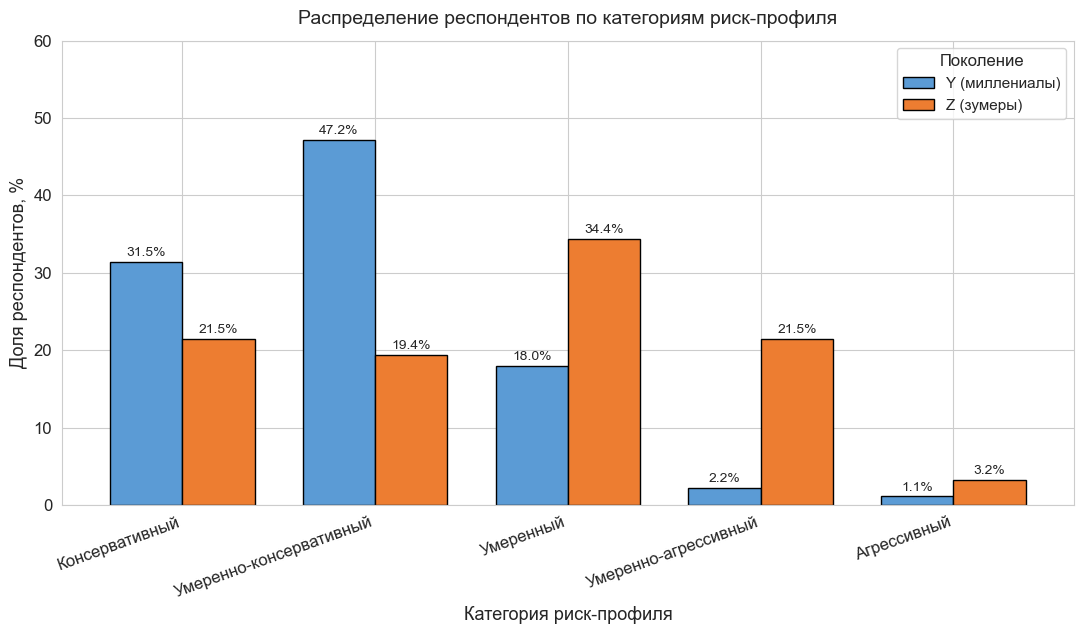

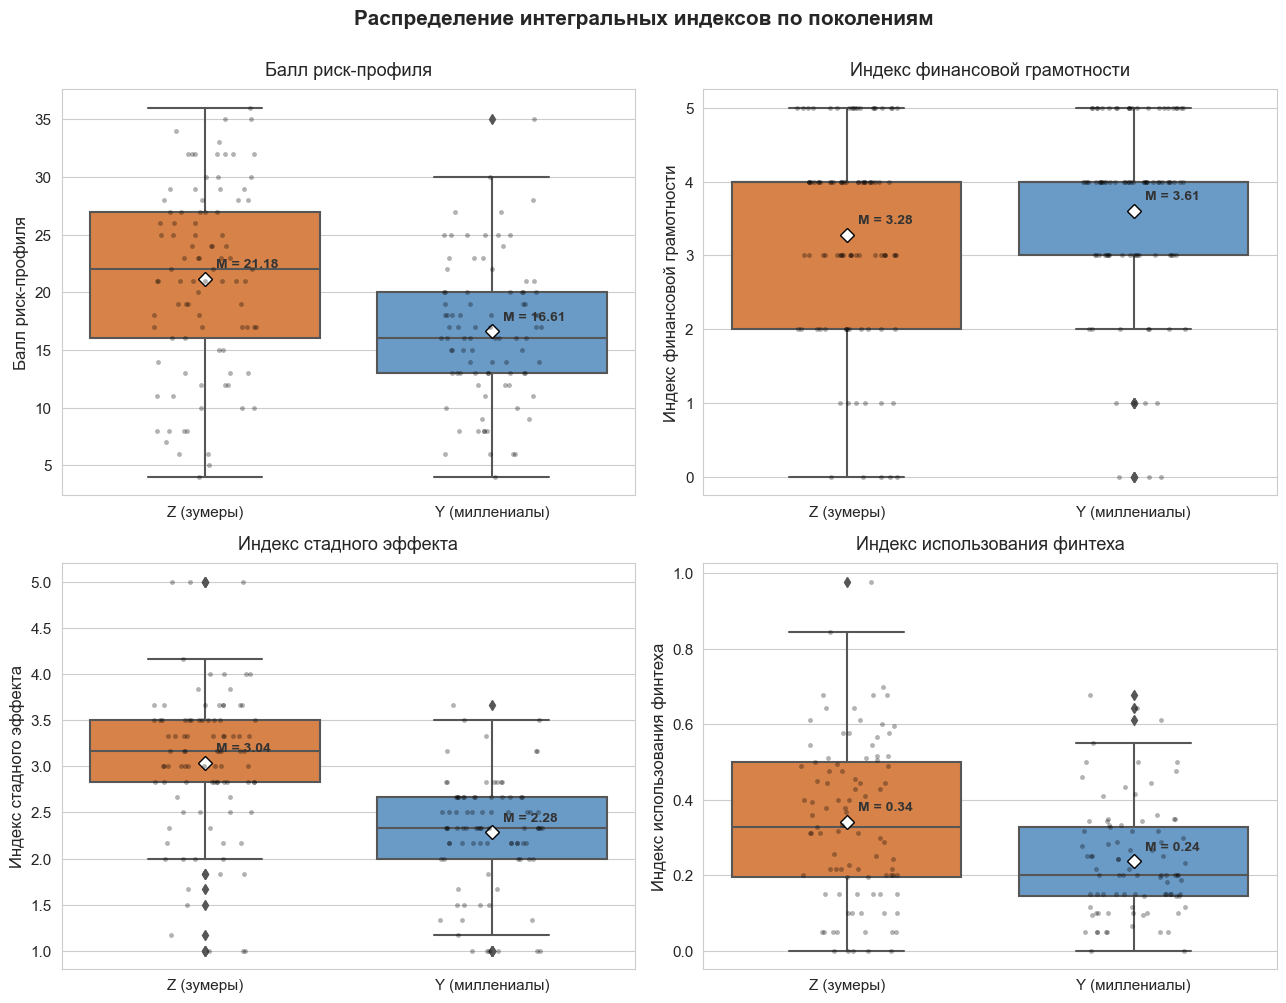

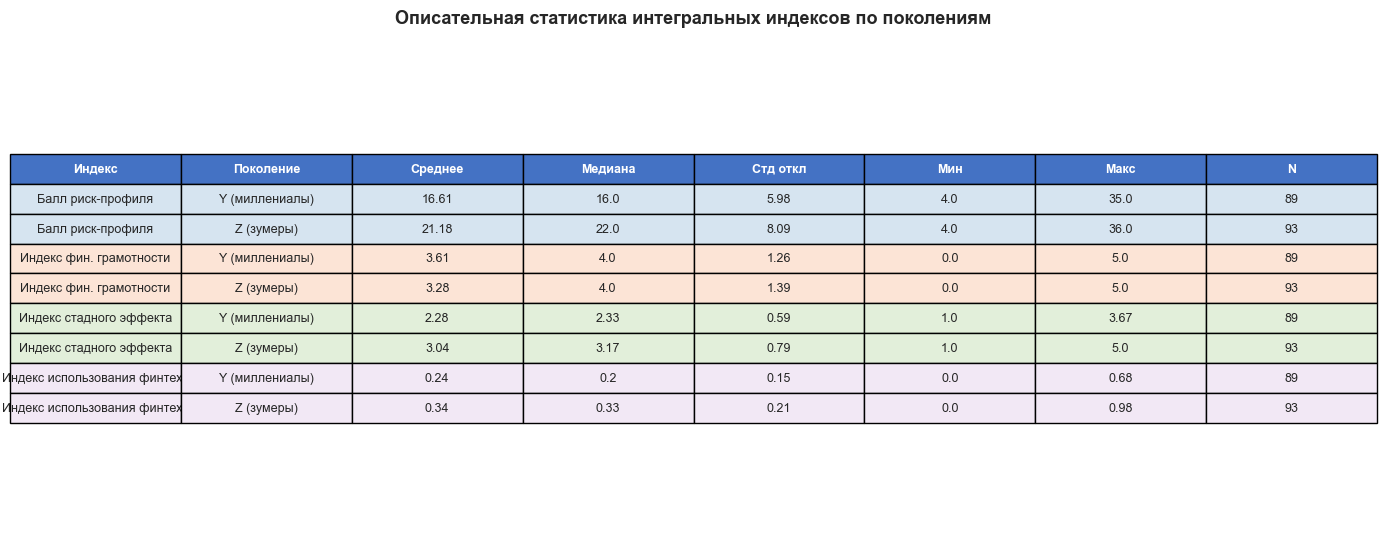

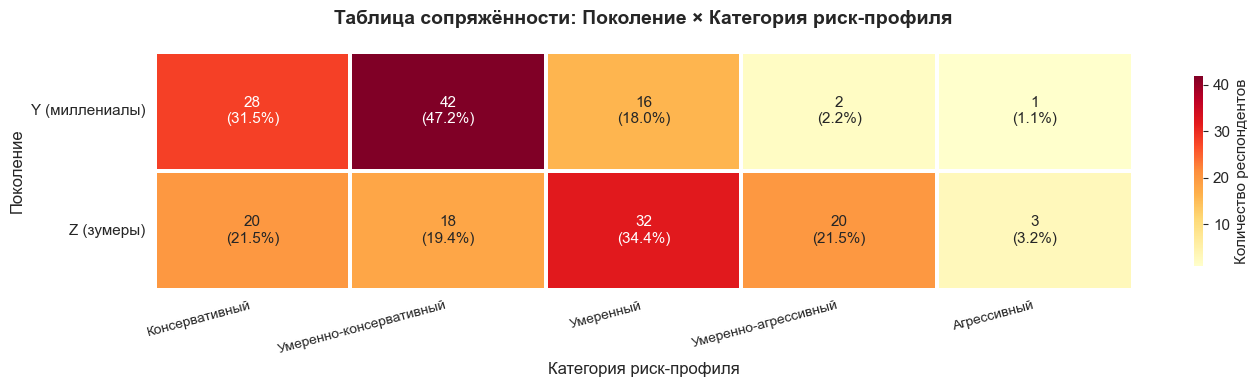

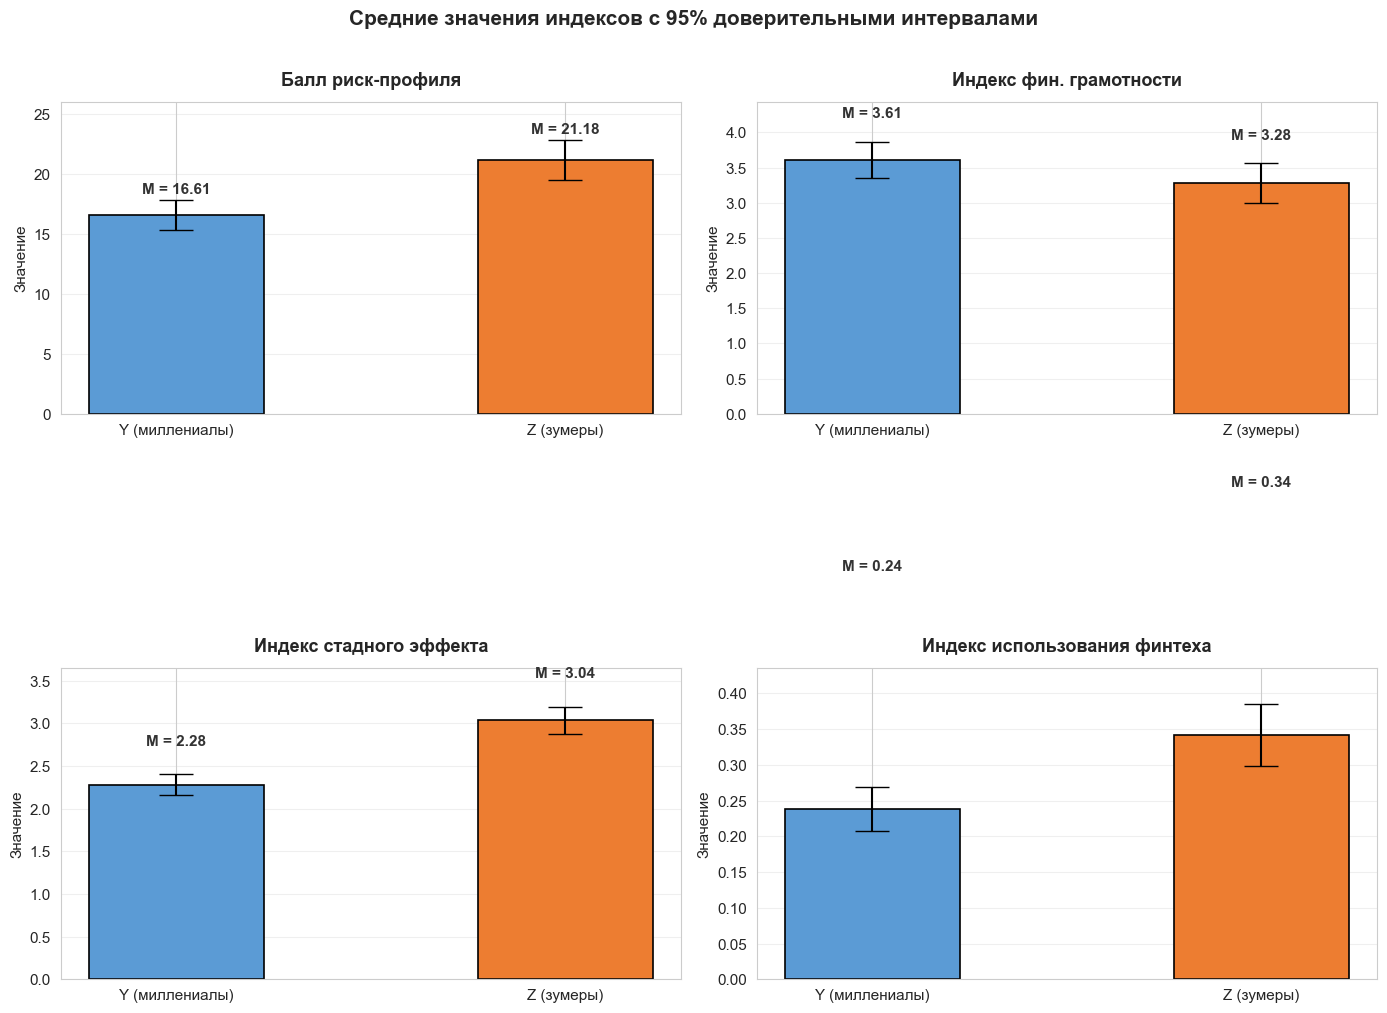

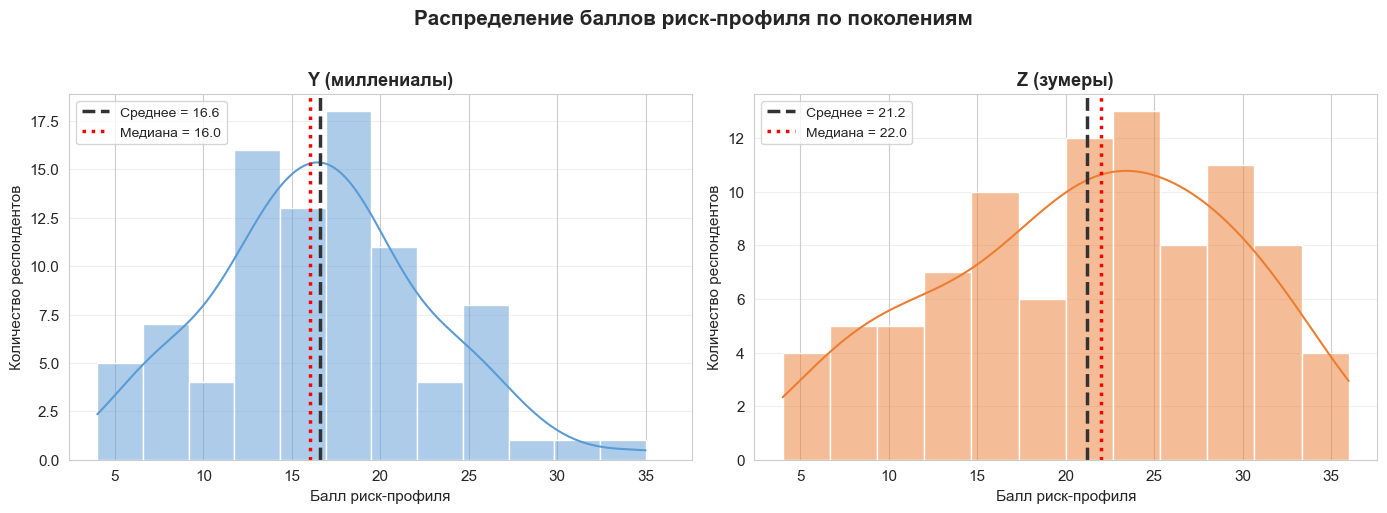

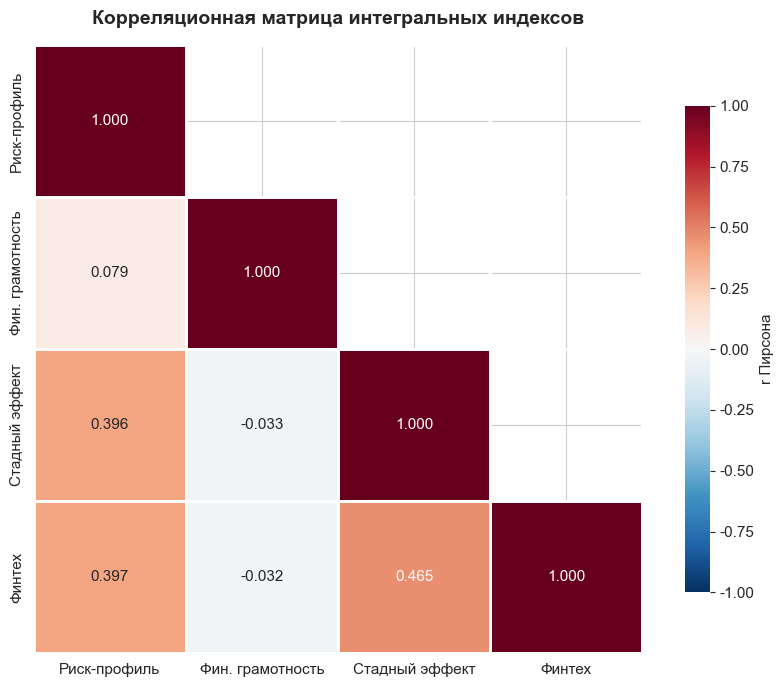

РЕЗУЛЬТАТЫ АНАЛИЗА

Объём выборки: 182 респондентов
  Миллениалы (Y): 89
  Зумеры (Z):     93

--- Описательная статистика ---
               risk_score                             literacy_score                             herding_score                                 fintech_score                                
                     mean median    std min max count           mean median    std min max count          mean median    std  min    max count          mean median    std  min    max count
generation                                                                                                                                                                                  
Y (миллениалы)     16.607   16.0  5.982   4  35    89          3.607    4.0  1.258   0   5    89         2.283  2.333  0.592  1.0  3.667    89         0.238  0.200  0.148  0.0  0.678    89
Z (зумеры)         21.183   22.0  8.085   4  36    93          3.280    4.0  1.394   0   5    93         3.036  3.167

In [114]:
results = run_full_analysis(df_full, output_dir='.')
report = print_report(results, df_full)
print(report)


In [117]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

model_df = df_full.dropna(subset=["risk_score", "gen_binary", "literacy_score", "herding_score", "fintech_score"])
X = model_df[["gen_binary", "literacy_score", "herding_score", "fintech_score"]]
X = sm.add_constant(X)
vif_data = pd.DataFrame({
    "Переменная": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print("Проверка мультиколлинеарности (VIF):")
print(vif_data.round(2))


Проверка мультиколлинеарности (VIF):
       Переменная    VIF
0           const  19.77
1      gen_binary   1.32
2  literacy_score   1.02
3   herding_score   1.54
4   fintech_score   1.28


In [116]:
corr_vars = ["risk_score", "literacy_score", "herding_score", "fintech_score"]
corr_matrix = df_full[corr_vars].corr()
print("Корреляционная матрица:")
print(corr_matrix.round(3))

Корреляционная матрица:
                risk_score  literacy_score  herding_score  fintech_score
risk_score           1.000           0.079          0.396          0.397
literacy_score       0.079           1.000         -0.033         -0.032
herding_score        0.396          -0.033          1.000          0.465
fintech_score        0.397          -0.032          0.465          1.000
